## Frequency plots for  Total CD4 T cells 

In [1]:

# load libraries
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library(tidyverse)
quiet_library(Seurat)
quiet_library(ggplot2)
quiet_library(Matrix)
quiet_library(dplyr)
quiet_library(viridis)
quiet_library(future)
quiet_library(future.apply)
quiet_library(SingleCellExperiment)
quiet_library(knitr)
quiet_library(plotly)
quiet_library(lme4)
quiet_library(ggrepel)
quiet_library(ggthemes)
quiet_library(GSVA)
quiet_library(tidyr)
quiet_library(SummarizedExperiment)
quiet_library(cowplot)

In [2]:
# Check number of cores
future::availableCores()
# Set up parallel processing to run when using 'future' functions 
future::plan(strategy = "multicore", workers = future::availableCores()-5)  
options(future.globals.maxSize = 1000 * 1024^3)
# to turn off parallel processing run line below
# future::plan(strategy = "sequential")

system 
    64

In [3]:
# define the color palette to be used
npg_color <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF", 
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF")
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c("#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", 
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999", 
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")
coolors_clrs<-c("#EFB0A1","#009FF5","#1A5E9B","#42E2B8","#4ECDC4","#89B6A5","#F1D26A","#D5B0AC","#EDABB1","#02504D","#AA9674","#E64B35FF","#4DBBD5FF","#00A087FF")

cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width =5, repr.plot.height =5)

In [4]:
fig_path="/home/workspace/ALTRA_DC/ALTRA_ANALYSIS/Deep_clean/Review_1/output_figs"

In [5]:
#' # Example usage of PlotFreqLinePlot function
#' # This function plots frequency line plots with model predictions.
#' PlotFreqLinePlot1(frequency_table, model_fit, palette, fig_path = "path/to/save", fig_name = "fig_name",
#'                  x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
#'                  shape_var = "sex", title = "Cluster 9", x_label = "Days to Conversion", 
#'                  y_label = "CLR", annotation_text = "p=0.055", annotation_x = -600, 
#'                  annotation_y = 1, annotation_color = "red")
#'
#' @export
#' @param frequency_table The input data frame containing frequency values to plot.
#' @param model_fit A fitted model object for predictions.
#' @param palette A color palette for the plot.
#' @param fig_path The file path where the plot will be saved (optional).
#' @param fig_name The name of the file where the plot will be saved (optional).
#' @param x_var The variable for the x-axis (default is "days_to_conversion").
#' @param y_var The variable for the y-axis (default is "clr").
#' @param color_var The variable to determine line colors (default is "subject.subjectGuid").
#' @param shape_var The variable to determine point shapes (default is "sex").
#' @param title The title of the plot.
#' @param x_label The x-axis label (default is "Days to Conversion").
#' @param y_label The y-axis label (default is "CLR").
#' @param annotation_text Text for annotation on the plot.
#' @param annotation_x X coordinate for the annotation.
#' @param annotation_y Y coordinate for the annotation.
#' @param annotation_color Color of the annotation text.
PlotFreqLinePlot1 <- function(frequency_table, model_fit, palette, fig_path = NULL, fig_name = NULL,
                             x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
                             shape_var = "sex", title = "Cluster 9", x_label = "Days to Conversion", 
                             y_label = "CLR", 
                              #annotation_text = "padj=", 
                              annotation_x = -600, 
                             annotation_y = 1, annotation_color = "red", x_limits = NULL, y_limits = NULL) {
    require(ggplot2)
    require(ggeffects)

    # Extract the prediction data frame
    pred.mm <- ggpredict(model_fit, terms = c(x_var))  # Adjusted to use x_var

    # plot
    p1 <- frequency_table %>%
        ggplot() +
        geom_line(aes(x = .data[[x_var]], y = .data[[y_var]], color = .data[[color_var]]), size = 1) + 
        geom_point(aes(x = .data[[x_var]], y = .data[[y_var]], shape = .data[[shape_var]])) + 
        geom_line(data = pred.mm, aes(x = x, y = predicted), color = "#8F7700FF", size = 2) +          
        geom_ribbon(data = pred.mm, aes(x = x, ymin = predicted - 3 * std.error, ymax = predicted + 3 * std.error), 
                    fill = "#8F7700FF", alpha = 0.3) + 
        #annotate(geom = "text", x = annotation_x, y = annotation_y, label = annotation_text, size = 6,
                # color = annotation_color) +
        labs(title = title) + 
        xlab(x_label) +  
        ylab(y_label) +
        scale_color_manual(values = palette) + 
        theme_few()+
        theme(
            text = element_text(size = 10, face = "bold"),  
            axis.title = element_text(size = 10, face = "bold"),  
            axis.text = element_text(size = 10, face = "bold"),  
            plot.title = element_text(size = 10, face = "bold"),  
            legend.position = "none",  # Remove all legends
            panel.grid.minor = element_blank(),
            panel.grid.major = element_blank(),
            panel.background = element_blank()
        ) +
        scale_shape_manual(values = c(1, 2))  # No need for guides() here

    # Adjust the scale of x and y axes if limits are provided
    if (!is.null(x_limits)) {
        p1 <- p1 + scale_x_continuous(limits = x_limits)
    }
    if (!is.null(y_limits)) {
        p1 <- p1 + scale_y_continuous(limits = y_limits)
    }

    # Code to save the plot if fig_path and fig_name are provided
    if (!missing(fig_path) && !missing(fig_name) && nzchar(fig_path) && nzchar(fig_name)) {
        # Construct the full file path with the figure name and desired file extension
        file_name <- paste0(fig_path, "/", fig_name)
        # Use ggsave to save the plot
        ggsave(file_name, plot = p1, width = 4, height = 4, dpi = 300)
    }
    return(p1)
}


In [7]:
## reading the frequency results
fq_clr=read.csv("/home/workspace/ALTRA_DC/ALTRA_ANALYSIS/Deep_clean/Review_1/output_files/DA/ALTRA_Certpro_DC_CD4_T_Treg_AIFI_L2_Frequency_new.csv")
fq_clr%>%head(3)
fq_clr%>%dim

,X,sample.sampleKitGuid,subject.subjectGuid,counts_of_C3,total_counts_CD4T_Treg,frequency_live,cluster_column,cluster,celltypes,days_to_conversion,age_conv,bmi_conv,subject.biologicalSex
,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>
1,1,KT00474,CU1043,114,6092,0.01871307,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,NA,NA,NA,Female
2,2,KT02284,SD1021,522,4130,0.12639225,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,NA,NA,NA,Female
3,3,KT02978,CU1078,273,6211,0.04395427,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,NA,NA,NA,Female


[1] 141  13

In [8]:
meta=read.csv("/home/workspace/ALTRA_DC//ALTRA_ANALYSIS/Deep_clean/AIM3/input_csv_files/2023-11-22_ALTRA_Metadata_labs.csv")

In [9]:
meta_filtered <- meta %>% 
  filter(subject.subjectGuid != "CU1015")
## becuase CU1015 is not used in longitudinal analysis

In [10]:
meta_a3=meta_filtered%>%filter(Status_Long %in% c("pre","conversion"))
meta_a3=select(meta_a3,c(Status_Long,sample.sampleKitGuid))
meta_a3%>%dim
meta_a3%>%head(2)

[1] 73  2

,Status_Long,sample.sampleKitGuid
,<chr>,<chr>
1,pre,KT00052
2,pre,KT00056


In [11]:
A3_clr <- merge(meta_a3, fq_clr, by='sample.sampleKitGuid', all.x=TRUE)
A3_clr%>%dim
A3_clr%>%head

[1] 73 14

,sample.sampleKitGuid,Status_Long,X,subject.subjectGuid,counts_of_C3,total_counts_CD4T_Treg,frequency_live,cluster_column,cluster,celltypes,days_to_conversion,age_conv,bmi_conv,subject.biologicalSex
,<chr>,<chr>,<int>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>
1,KT00052,pre,92,CU1009,239,9202,0.02597261,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-714,58,25.64892,Female
2,KT00056,pre,66,CU1007,206,6252,0.03294946,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-632,44,26.19498,Female
3,KT00057,pre,120,CU1003,129,4647,0.02775985,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-615,23,23.14306,Female
4,KT00064,pre,116,CU1010,192,5165,0.03717328,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-1144,62,24.55026,Female
5,KT00075,pre,57,CU1021,271,8155,0.03323115,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-1037,68,25.66073,Male
6,KT00082,pre,67,CU1007,120,4700,0.02553191,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-540,44,26.19498,Female


In [12]:
altra=read.csv("/home/workspace/ALTRA_DC//ALTRA_ANALYSIS/Deep_clean/Figure_notebooks/files/input_files/certpro_Zi_files/Figure_input_files/ALTRA_Fig1_Master_meta
                    .csv")
altra%>%head(3)
altra=select(altra,c("sample.sampleKitGuid","s1_ids","Status_new"))
altra%>%head(3)


,X,Status_Xsec,Status_Long,sample.sampleKitGuid,sample.drawDate,sample.daysSinceFirstVisit,subject.subjectGuid,subject.biologicalSex,subject.birthYear,days_to_conversion,number_of_days_to_from_ra_conversion_cu,anti_ccp3_finalCombined,status,time,s1,s1_ids,Status_new
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>
1,1,ALTRA_healthy,NA,KT02284,2022-10-01,0,SD1021,Female,1971,NA,NA,0,ALTRA_healthy,-2000,CON1,CON101,CON1
2,2,ALTRA_healthy,NA,KT02286,2022-08-01,0,SD1022,Female,1985,NA,NA,2,ALTRA_healthy,-2000,CON1,CON102,CON1
3,3,ALTRA_healthy,NA,KT02287,2022-05-01,0,SD1015,Female,1963,NA,NA,0,ALTRA_healthy,-2000,CON1,CON103,CON1


,sample.sampleKitGuid,s1_ids,Status_new
,<chr>,<chr>,<chr>
1,KT02284,CON101,CON1
2,KT02286,CON102,CON1
3,KT02287,CON103,CON1


In [13]:
A3_clr1 <- left_join(A3_clr, altra, by = "sample.sampleKitGuid",)
A3_clr1%>%head(3)
A3_clr1%>%dim

,sample.sampleKitGuid,Status_Long,X,subject.subjectGuid,counts_of_C3,total_counts_CD4T_Treg,frequency_live,cluster_column,cluster,celltypes,days_to_conversion,age_conv,bmi_conv,subject.biologicalSex,s1_ids,Status_new
,<chr>,<chr>,<int>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>
1,KT00052,pre,92,CU1009,239,9202,0.02597261,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-714,58,25.64892,Female,ARI36,LONG
2,KT00056,pre,66,CU1007,206,6252,0.03294946,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-632,44,26.19498,Female,ARI46,LONG
3,KT00057,pre,120,CU1003,129,4647,0.02775985,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-615,23,23.14306,Female,ARI35,LONG


[1] 73 16

In [14]:
##filtering out samples having less than -750 days to conversion
A3_clr_v1<- A3_clr1 %>%
  filter(days_to_conversion >= -750)
A3_clr_v1%>%dim

[1] 59 16

In [15]:
## removing the male samples to run the lm model
A3_clr_v2 <- A3_clr_v1 %>%
  filter(subject.biologicalSex != "Male")
A3_clr_v2%>%dim

[1] 50 16

In [16]:
A3_clr_v2

sample.sampleKitGuid,Status_Long,X,subject.subjectGuid,counts_of_C3,total_counts_CD4T_Treg,frequency_live,cluster_column,cluster,celltypes,days_to_conversion,age_conv,bmi_conv,subject.biologicalSex,s1_ids,Status_new
<chr>,<chr>,<int>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>
KT00052,pre,92,CU1009,239,9202,0.02597261,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-714,58,25.64892,Female,ARI36,LONG
KT00056,pre,66,CU1007,206,6252,0.03294946,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-632,44,26.19498,Female,ARI46,LONG
KT00057,pre,120,CU1003,129,4647,0.02775985,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-615,23,23.14306,Female,ARI35,LONG
KT00082,pre,67,CU1007,120,4700,0.02553191,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-540,44,26.19498,Female,ARI46,LONG
KT00084,pre,70,CU1029,500,11087,0.04509786,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-614,66,28.67547,Female,ARI37,LONG
KT00099,pre,35,CU1003,155,5167,0.02999806,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-516,23,23.14306,Female,ARI35,LONG
KT00103,pre,82,SD1003,289,5345,0.05406922,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-80,36,25.65487,Female,ARI32,LONG
KT00105,pre,81,SD1007,307,7603,0.04037880,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,-92,32,26.02500,Female,ARI33,LONG
KT00109,conversion,114,SD1003,305,5764,0.05291464,C3 from cd4 mem,cluster3,CD4 T (naive+memory) & Treg,0,36,25.65487,Female,ARI32,LONG


# Memory CD4 T cell

In [18]:
# Memory CD4 T cell
  c3_df <- A3_clr_v2 %>% filter(cluster == "cluster3")
  
  # Fit the linear mixed-effects model
  model_C3 <- lmerTest::lmer(frequency_live ~ age_conv + bmi_conv + days_to_conversion + (1 | subject.subjectGuid), data = c3_df)

In [19]:
c3_df%>%dim

[1] 50 16

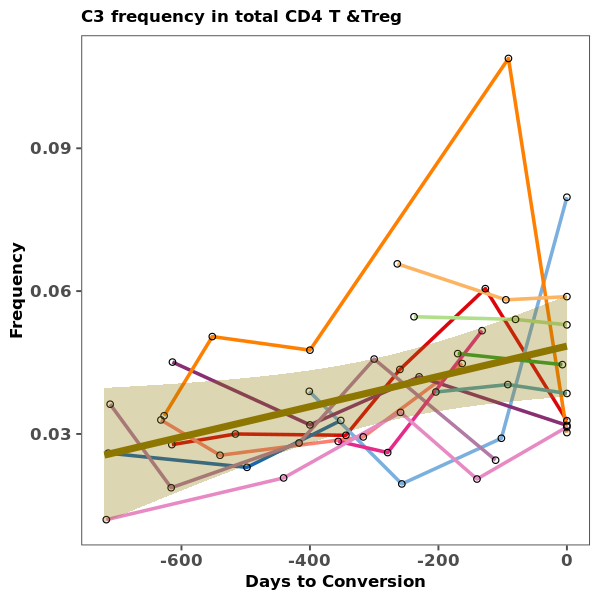

In [22]:
PlotFreqLinePlot1(c3_df %>% mutate(Sex=subject.biologicalSex), model_fit=model_C3, palette=cluster_colors,
                 fig_path = fig_path,fig_name ="Frequency_Plot_c3_total_CD4_T&Treg_final.pdf",
                  x_var = "days_to_conversion", y_var = "frequency_live", color_var = "subject.subjectGuid",
                  shape_var = "Sex", title = "C3 frequency in total CD4 T &Treg", x_label = "Days to Conversion", 
                  y_label = "Frequency", 
                 #annotation_text = "padj=0.030",
                  annotation_x = -600, 
                  annotation_y =1.7, annotation_color = "black")

In [26]:
sessionInfo()

R version 4.3.1 (2023-06-16)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 20.04.6 LTS

Matrix products: default
BLAS/LAPACK: /home/jupyter/libs/r_scrna/lib/libopenblasp-r0.3.24.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ggeffects_1.7.0             cowplot_1.1.3              
 [3] GSVA_1.48.3                 ggthemes_5.1.0             
 [5] ggrepel_0.9.5               lme4_1.1-34                
 [7] plotly_4.10.4               knitr_1.47                 
 [9] ggpubr_0.6.0                Seurat